## 1. Data Loading

Load the raw dataset using a reusable data loading function.

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))

from src.data_loading import load_data

In [3]:
file_path = r"C:\Users\DELL\Downloads\Sample - Superstore 2019 (1).xls"

df = load_data(file_path)

Dataset loaded successfully.


In [4]:
df.shape

(9994, 21)

## 2. Data Inspection

Before applying any cleaning operations, the dataset is inspected to understand its structure, data types, missing values, duplicate records, memory usage, unique values, and numerical characteristics.

In [5]:
from src.data_cleaning import (
    inspect_structure,
    inspect_missing_values,
    inspect_duplicates,
    inspect_memory_usage,
    inspect_unique_values,
    inspect_numerical_summary
)

### Dataset Structure

In [6]:
inspect_structure(df)

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit             

### Missing Values

In [7]:
inspect_missing_values(df)

,Missing Count
Postal Code,11


### Duplicate Records

In [8]:
inspect_duplicates(df)

np.int64(0)

### Memory Usage

In [9]:
inspect_memory_usage(df)

,Memory Usage (bytes)
Product Name,449496
Product ID,229862
Order ID,219868
Country/Region,209874
Customer Name,209570
Ship Mode,208106
Category,207901
City,173203
Segment,168273
State,164773


### Unique Values

In [10]:
inspect_unique_values(df)

,Unique Values
Country/Region,1
Segment,3
Category,3
Ship Mode,4
Region,4
Discount,12
Quantity,14
Sub-Category,17
State,49
City,531


### Numerical Summary

In [11]:
inspect_numerical_summary(df)

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2018-04-30 10:03:51.979187,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,2018-05-04 09:03:29.645787,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Postal Code,9983.0,55245.233297,1040.0,23223.0,57103.0,90008.0,99301.0,32038.715955
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108


## Data Cleaning



In [12]:
from src.data_cleaning import (
    handle_missing_values,
    remove_duplicates,
    optimize_data_types,
    clean_inconsistent_values,
    detect_outliers_iqr,
    validate_cleaned_data,
    get_memory_usage,
    clean_dataset
) 

In [13]:
df = clean_dataset(df)

No duplicate records found.


### Memory Optimization

In [14]:
print(df.dtypes)

Row ID                     int16
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode               category
Customer ID                  str
Customer Name                str
Segment                 category
Country/Region          category
City                         str
State                        str
Postal Code                Int64
Region                  category
Product ID                   str
Category                category
Sub-Category            category
Product Name                 str
Sales                    float64
Quantity                    int8
Discount                 float32
Profit                   float32
dtype: object


In [15]:

memory_before = get_memory_usage(df)

print(f"Memory Before Optimization: {memory_before:.2f} MB")

Memory Before Optimization: 2.02 MB


In [16]:
df = optimize_data_types(df)

In [17]:
print(df.dtypes)

Row ID                     int16
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode               category
Customer ID                  str
Customer Name                str
Segment                 category
Country/Region          category
City                         str
State                        str
Postal Code                Int64
Region                  category
Product ID                   str
Category                category
Sub-Category            category
Product Name                 str
Sales                    float64
Quantity                    int8
Discount                 float32
Profit                   float32
dtype: object


In [18]:
memory_after = get_memory_usage(df)

print(f"Memory After Optimization: {memory_after:.2f} MB")

Memory After Optimization: 2.02 MB


###  Outlier Detection

In [19]:
outlier_summary = detect_outliers_iqr(
    df,
    columns=[
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Sales,17.28000,209.940,192.66000,-271.710000,498.930000,1167
1,Quantity,2.00000,5.000,3.00000,-2.500000,9.500000,170
2,Discount,0.00000,0.200,0.20000,-0.300000,0.500000,856
3,Profit,1.72875,29.364,27.63525,-39.724125,70.816876,1881


###  Data Validation

In [20]:
validate_cleaned_data(df)

Rows                 9994
Columns                21
Missing Values         11
Duplicate Records       0
Negative Sales          0
Negative Quantity       0
Invalid Discount        0
dtype: int64

### Final Data Types

In [21]:
df.dtypes

Row ID                     int16
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode               category
Customer ID                  str
Customer Name                str
Segment                 category
Country/Region          category
City                         str
State                        str
Postal Code                Int64
Region                  category
Product ID                   str
Category                category
Sub-Category            category
Product Name                 str
Sales                    float64
Quantity                    int8
Discount                 float32
Profit                   float32
dtype: object

### Final Memory Usage

In [22]:
memory_final = get_memory_usage(df)

print(f"Final Memory Usage: {memory_final:.2f} MB")

Final Memory Usage: 2.02 MB


## Feature Engineering

In [23]:
from src.feature_engineering import engineer_features

In [24]:
df = engineer_features(df)

In [25]:
df[
    [
        "Sales",
        "Profit",
        "Profit Margin",
        "Order Date",
        "Ship Date",
        "Shipping Duration",
        "Sales Performance Category"
    ]
].head()

,Sales,Profit,Profit Margin,Order Date,Ship Date,Shipping Duration,Sales Performance Category
0,261.9600,41.913601,0.1600,2018-11-08,2018-11-11,3,High
1,731.9400,219.582001,0.3000,2018-11-08,2018-11-11,3,High
2,14.6200,6.871400,0.4700,2018-06-12,2018-06-16,4,Low
3,957.5775,-383.031006,-0.4000,2017-10-11,2017-10-18,7,High
4,22.3680,2.516400,0.1125,2017-10-11,2017-10-18,7,Low


### Data Analysis

In [26]:
from src.data_analysis import analyze_data

analysis_results = analyze_data(df)


In [27]:
analysis_results["category_performance"]


,Sales,Profit
Category,,
Technology,836154.0330,145454.953125
Furniture,741999.7953,18451.273438
Office Supplies,719047.0320,122490.804688


In [28]:
analysis_results["profit_by_subcategory"]


Sub-Category
Copiers        55617.824219
Phones         44515.730469
Accessories    41936.636719
Paper          34053.570312
Binders        30221.763672
Chairs         26590.166016
Storage        21278.826172
Appliances     18138.005859
Furnishings    13059.143555
Envelopes       6964.176758
Art             6527.787109
Labels          5546.253906
Machines        3384.756836
Fasteners        949.518188
Supplies       -1189.099487
Bookcases      -3472.556152
Tables        -17725.480469
Name: Profit, dtype: float32

In [29]:
analysis_results["regional_performance"]


,Sales,Profit
Region,,
West,725457.8245,108418.445312
East,678781.2400,91522.781250
Central,501239.8908,39706.363281
South,391721.9050,46749.429688


In [30]:
analysis_results["city_performance"]


,Sales,Profit
City,,
New York City,256368.1610,62036.984375
Los Angeles,175851.3410,30440.757812
Seattle,119540.7420,29156.097656
San Francisco,112669.0920,17507.384766
Philadelphia,109077.0130,-13837.767578
Houston,64504.7604,-10153.548828
Chicago,48539.5410,-6654.568848
San Diego,47521.0290,6377.195801
Jacksonville,44713.1830,-2323.834961


In [31]:
analysis_results["discount_vs_profit_margin"]


,Discount,Profit Margin
0,0.00,0.1600
1,0.00,0.3000
2,0.00,0.4700
3,0.45,-0.4000
4,0.20,0.1125
...,...,...
9989,0.20,0.1625
9990,0.00,0.1700
9991,0.20,0.0750
9992,0.00,0.4500


In [32]:
analysis_results["sales_seasonality"]


Order Date
Jan 2016     14236.8950
Feb 2016      4519.8920
Mar 2016     55691.0090
Apr 2016     28295.3450
May 2016     23648.2870
Jun 2016     34595.1276
Jul 2016     33946.3930
Aug 2016     27909.4685
Sep 2016     81777.3508
Oct 2016     31453.3930
Nov 2016     78628.7167
Dec 2016     69545.6205
Jan 2017     18174.0756
Feb 2017     11951.4110
Mar 2017     38726.2520
Apr 2017     34195.2085
May 2017     30131.6865
Jun 2017     24797.2920
Jul 2017     28765.3250
Aug 2017     36898.3322
Sep 2017     64595.9180
Oct 2017     31404.9235
Nov 2017     75972.5635
Dec 2017     74919.5212
Jan 2018     18542.4910
Feb 2018     22978.8150
Mar 2018     51715.8750
Apr 2018     38750.0390
May 2018     56987.7280
Jun 2018     40344.5340
Jul 2018     39261.9630
Aug 2018     31115.3743
Sep 2018     73410.0249
Oct 2018     59687.7450
Nov 2018     79411.9658
Dec 2018     96999.0430
Jan 2019     43971.3740
Feb 2019     20301.1334
Mar 2019     58872.3528
Apr 2019     36521.5361
May 2019     44261.1102
Jun 2

In [33]:
analysis_results["profit_distribution_by_category"]


,Category,Profit
0,Furniture,41.913601
1,Furniture,219.582001
2,Office Supplies,6.871400
3,Furniture,-383.031006
4,Office Supplies,2.516400
...,...,...
9989,Furniture,4.102800
9990,Furniture,15.633200
9991,Technology,19.393200
9992,Office Supplies,13.320000


In [34]:
analysis_results["profit_by_region_category"]

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.049316,8879.980469,33697.429688
East,3046.165527,41014.578125,47462.035156
South,6771.206055,19986.392578,19991.832031
West,11504.950195,52609.847656,44303.648438


### Data Visualization

In [35]:
from src.data_analysis import analyze_data

analysis_results = analyze_data(df)


In [36]:
from src.visualization import (
    plot_category_performance,
    plot_profit_by_subcategory,
    plot_regional_performance,
    plot_city_performance,
    plot_discount_vs_profit_margin,
    plot_sales_seasonality,
    plot_profit_distribution,
    plot_profit_by_region_category
)

### Question 1 (Category Performance)

**Which categories generate the strongest combination of sales and profit?**

This analysis compares total sales and profit across product categories to identify which categories contribute most strongly to the company's overall financial performance.

<Figure size 900x600 with 0 Axes>

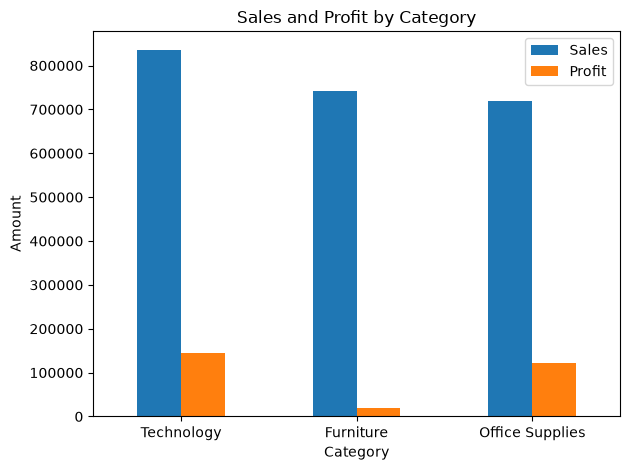

In [37]:
plot_category_performance(
    analysis_results["category_performance"]
)

### Question 2 (Sub-Category Profitability)

**Which sub-categories are the most and least profitable?**

This analysis ranks sub-categories based on total profit to identify the strongest contributors to profitability and the areas that may require further investigation.

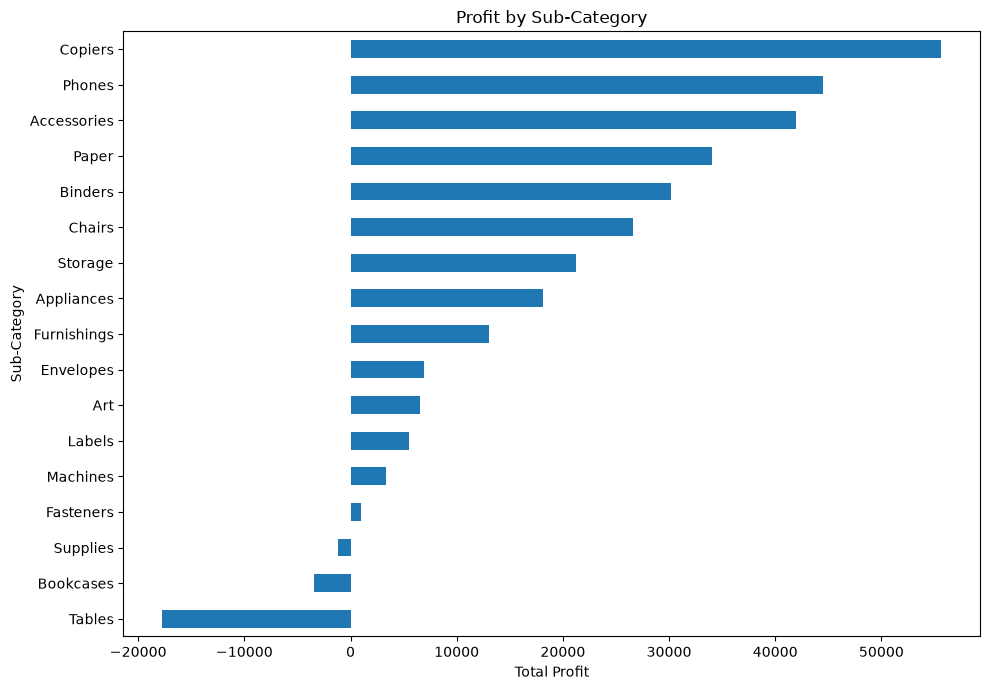

In [38]:
plot_profit_by_subcategory(
    analysis_results["profit_by_subcategory"]
)

### Question 3 (Regional Sales vs Profit)

**Are the regions generating the highest sales also generating the highest profit?**

This analysis examines the relationship between sales and profit across regions to determine whether strong revenue performance is consistently associated with strong profitability.

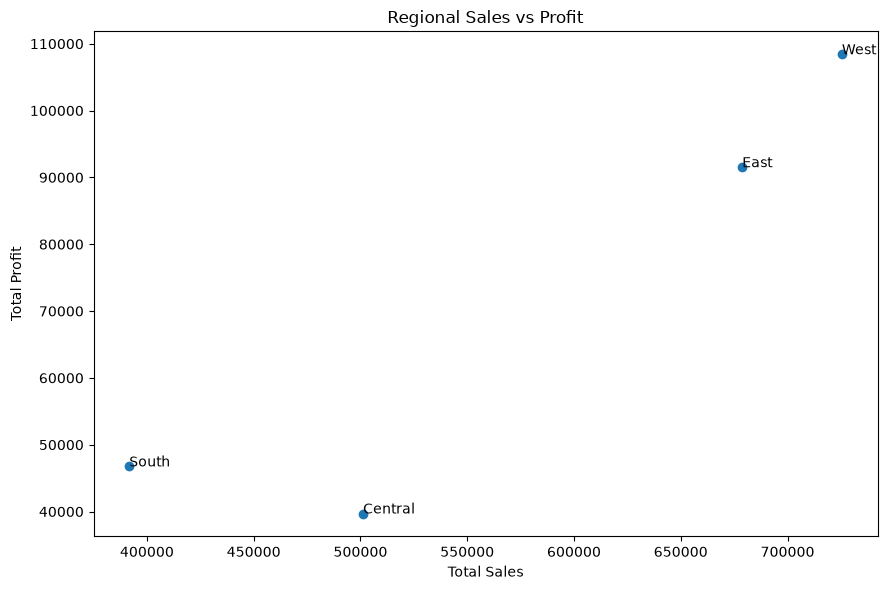

In [39]:
plot_regional_performance(
    analysis_results["regional_performance"]
)

### Business Question 4 (City Performance)

**Which cities generate the highest sales and profit?**

This analysis identifies the top-performing cities based on sales and profit to determine which geographic markets contribute most to the company's performance.

<Figure size 1000x800 with 0 Axes>

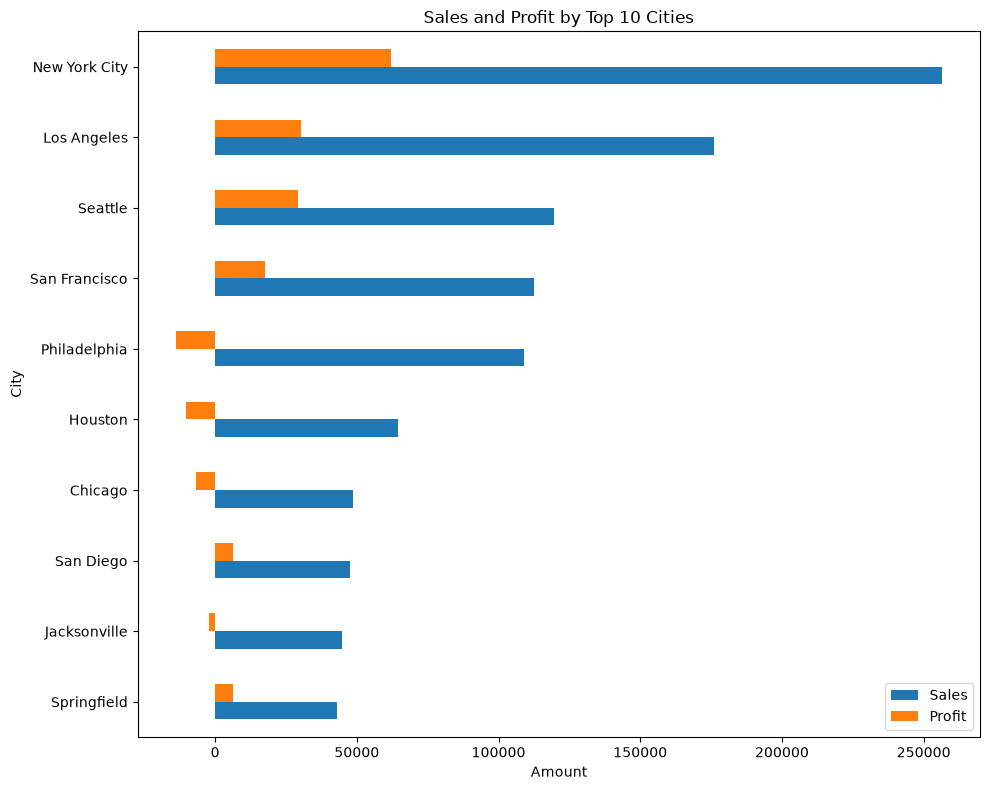

In [40]:
plot_city_performance(
    analysis_results["city_performance"]
)

### Business Question 5 (Discount vs Profit Margin)

**Does discount level affect profit margin?**

This analysis investigates the relationship between discount levels and profit margin to evaluate whether increasing discounts may negatively affect the company's profitability.

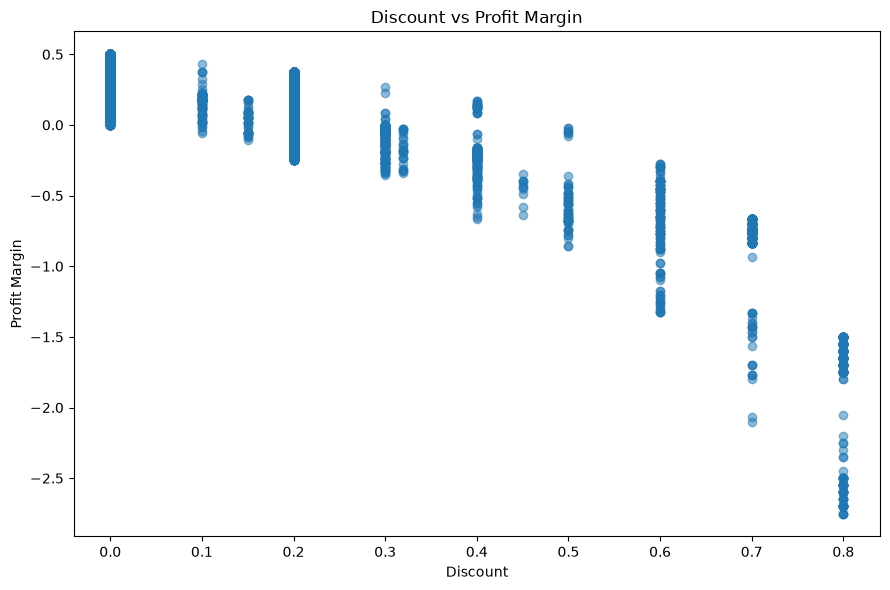

In [41]:
plot_discount_vs_profit_margin(
    analysis_results["discount_vs_profit_margin"]
)

### Question 6 (Sales Seasonality)

**Is there seasonality in sales across months or quarters?**

This analysis examines sales over time to identify recurring periods of higher or lower demand and determine whether seasonal patterns exist in the business.

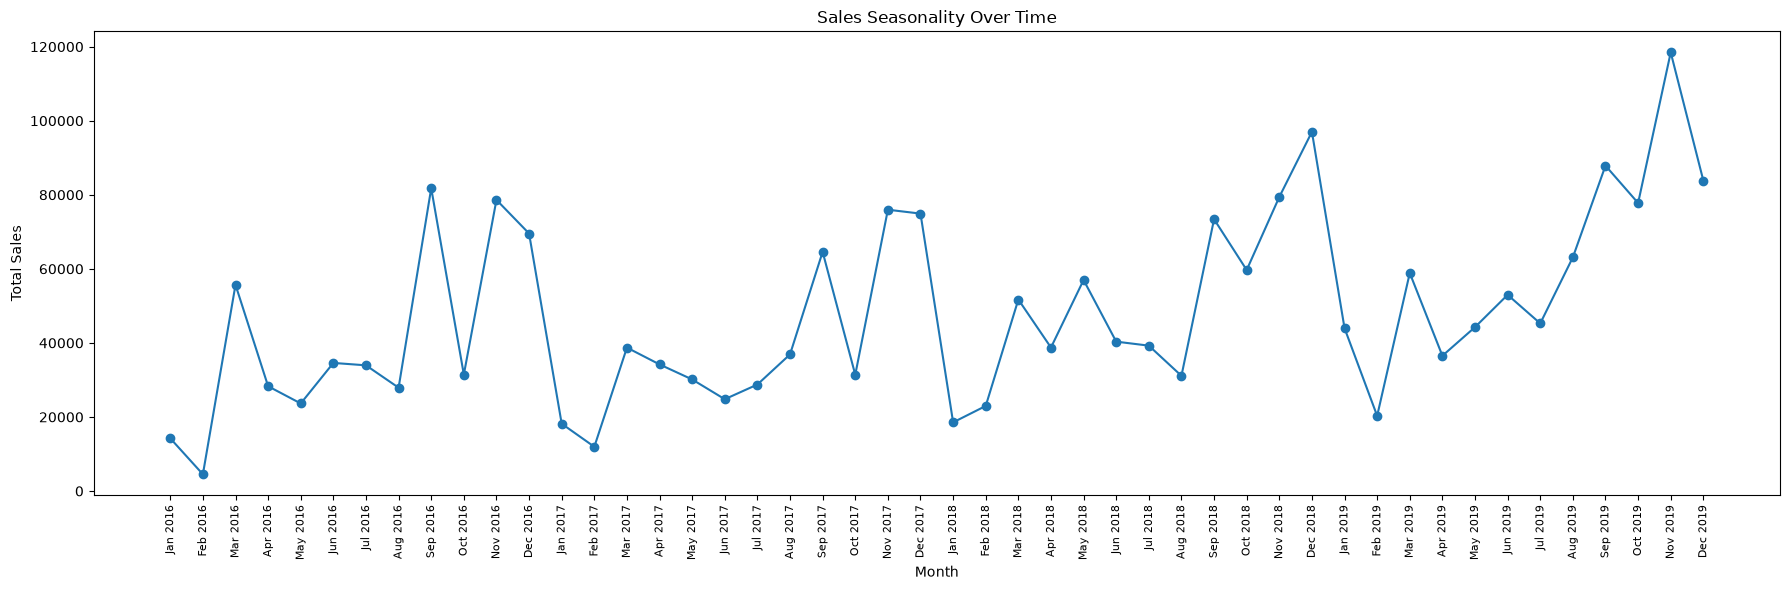

In [42]:
plot_sales_seasonality(
    analysis_results["sales_seasonality"]
)

### Question 7 (Profit Distribution by Category)

**Which categories have the most variable profitability?**

This analysis compares the distribution of profit across categories to identify differences in profitability consistency, spread, and extreme values.

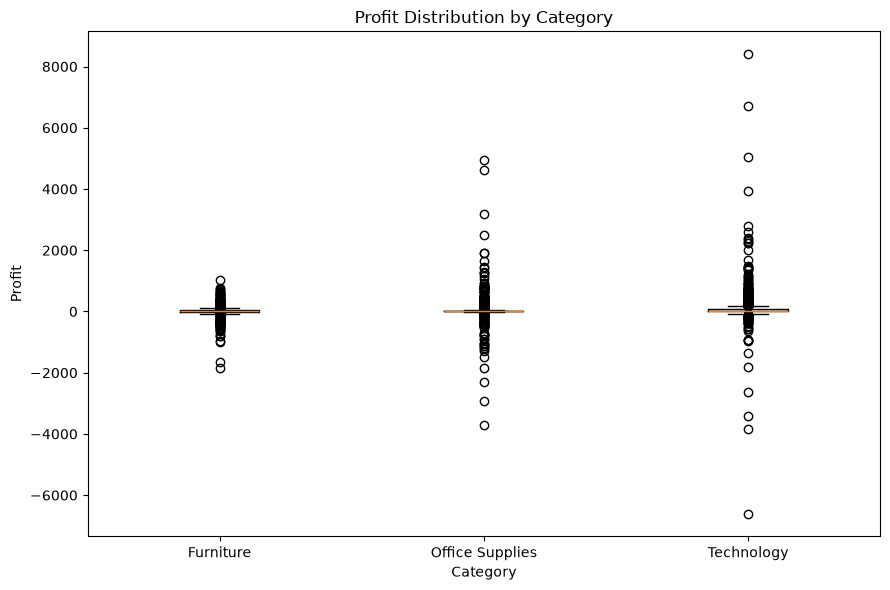

In [43]:
plot_profit_distribution(
    analysis_results["profit_distribution_by_category"]
)

### Question 8 (Region × Category Profitability)

**Which region-category combinations generate the strongest and weakest profit?**

This analysis evaluates profitability across both regions and product categories to identify combinations that perform particularly well or poorly.

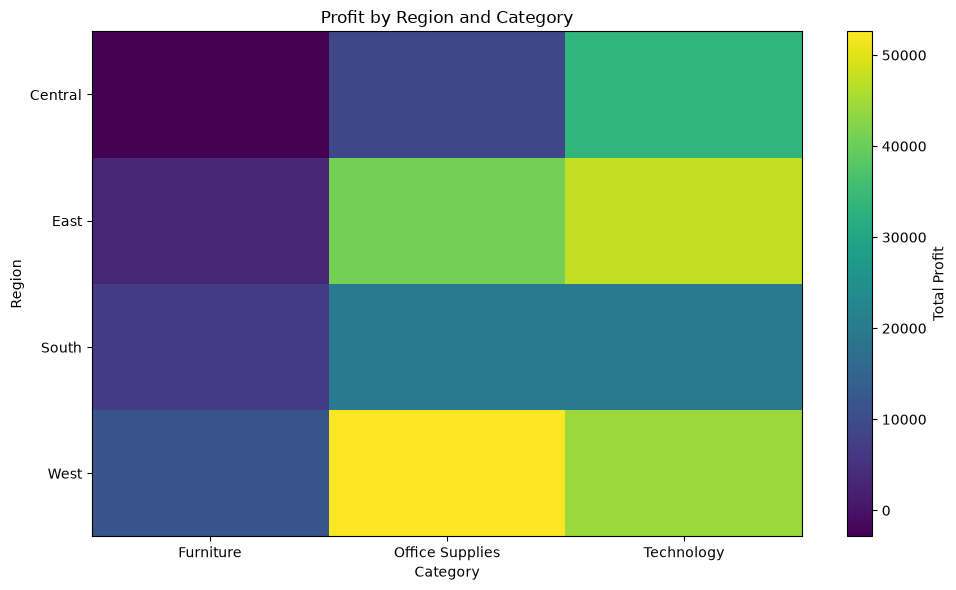

In [44]:
plot_profit_by_region_category(
    analysis_results["profit_by_region_category"]
)